<a href="https://colab.research.google.com/github/demsaid400-cpu/DI-BOOTCAMP/blob/main/Week4/Day4/DailyChallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [ ]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [5]:
file_1 = '/content/Churn_Modelling.csv'

In [29]:
df = pd.read_csv(file_1)
df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]

In [7]:
display(df.head())

NameError: name 'df' is not defined

In [9]:
df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]

NameError: name 'df' is not defined

## Hypothesis 1: Age

In [10]:
sns.histplot(data=df, x='Age', hue='Exited', kde=True, element='step')
plt.legend(title='Status', labels=['Exited', 'Stayed'])
plt.title('Age Distribution by Churn Status')
plt.show()

NameError: name 'df' is not defined

In [30]:
mean_age_stayed = df_0['Age'].mean()
std_age_stayed = df_0['Age'].std()
print(f'Stayed - Mean Age: {mean_age_stayed:.2f}, Std Dev: {std_age_stayed:.2f}')

Stayed - Mean Age: 37.41, Std Dev: 10.13


In [31]:
mean_age_left = df_1['Age'].mean()
std_age_left = df_1['Age'].std()
print(f'Left - Mean Age: {mean_age_left:.2f}, Std Dev: {std_age_left:.2f}')

Left - Mean Age: 44.84, Std Dev: 9.76


In [33]:
t_stat, p_val = scipy.stats.ttest_ind(df_0['Age'], df_1['Age'])
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value: {p_val:.4e}')

T-statistic: -29.7668
P-value: 1.2399e-186


### Using Bootstrapping

In [14]:
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, len(data))
        bs_s[i] = func(bs_abc)
    return bs_s

In [32]:
diff_means = mean_age_left - mean_age_stayed
overall_mean = df['Age'].mean()
age_stayed_shifted = df_0['Age'] - mean_age_stayed + overall_mean
age_left_shifted = df_1['Age'] - mean_age_left + overall_mean

In [34]:
bs_stayed = bs_choice(age_stayed_shifted, np.mean, 10000)
bs_left = bs_choice(age_left_shifted, np.mean, 10000)
bs_diff = bs_left - bs_stayed

In [35]:
p_value_bs = np.sum(bs_diff >= diff_means) / len(bs_diff)
print(f'Bootstrap p-value: {p_value_bs}')

Bootstrap p-value: 0.0


### Conclusion
**Reject the Null Hypothesis.** The p-value is extremely low (near zero) for both the t-test and bootstrap simulation. This indicates a statistically significant difference in age, with churned customers being significantly older on average.

## Hypothesis 2: Credit Score

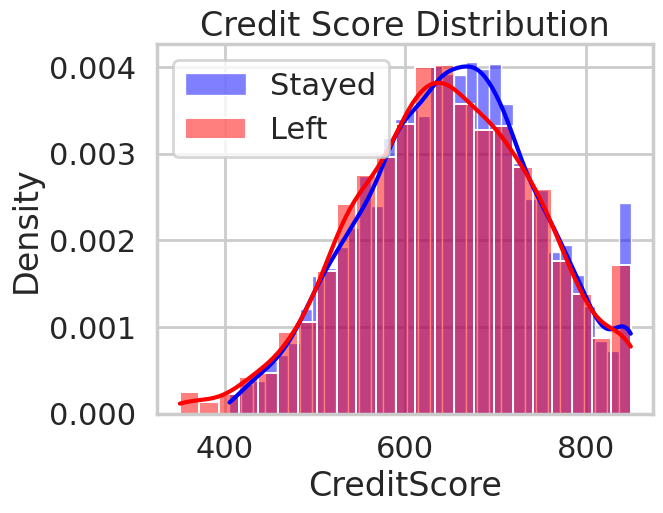

In [36]:
sns.histplot(df_0['CreditScore'], color='blue', label='Stayed', kde=True, stat='density', alpha=0.5)
sns.histplot(df_1['CreditScore'], color='red', label='Left', kde=True, stat='density', alpha=0.5)
plt.legend()
plt.title('Credit Score Distribution')
plt.show()

In [37]:
t_stat_credit, p_val_credit = scipy.stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'])
print(f'Credit Score T-statistic: {t_stat_credit:.4f}')
print(f'Credit Score P-value: {p_val_credit:.4f}')

Credit Score T-statistic: 2.7101
Credit Score P-value: 0.0067


### Conclusion
**Reject the Null Hypothesis.** The p-value (0.0067) is less than 0.05. While the distributions look similar visually, there is a statistically significant difference in credit scores between the two groups.

## Hypothesis 3: Balance

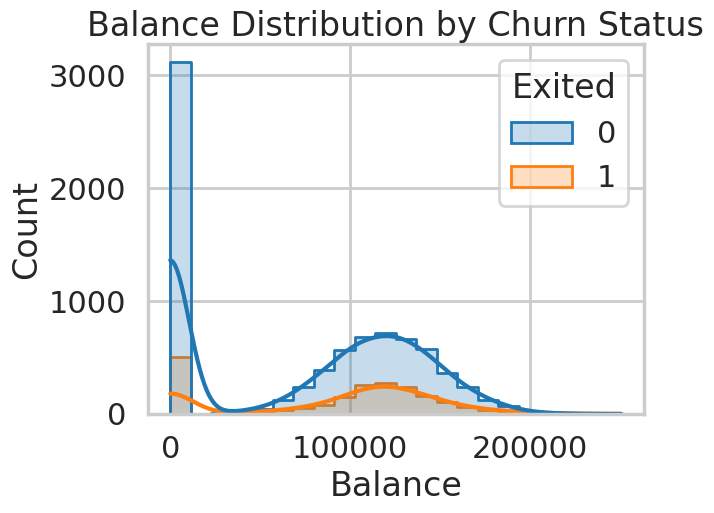

In [38]:
sns.histplot(data=df, x='Balance', hue='Exited', kde=True, element='step')
plt.title('Balance Distribution by Churn Status')
plt.show()

In [39]:
t_stat_bal, p_val_bal = scipy.stats.ttest_ind(df_0['Balance'], df_1['Balance'])
print(f'Balance T-statistic: {t_stat_bal:.4f}, P-value: {p_val_bal:.4e}')

Balance T-statistic: -11.9362, P-value: 1.2756e-32


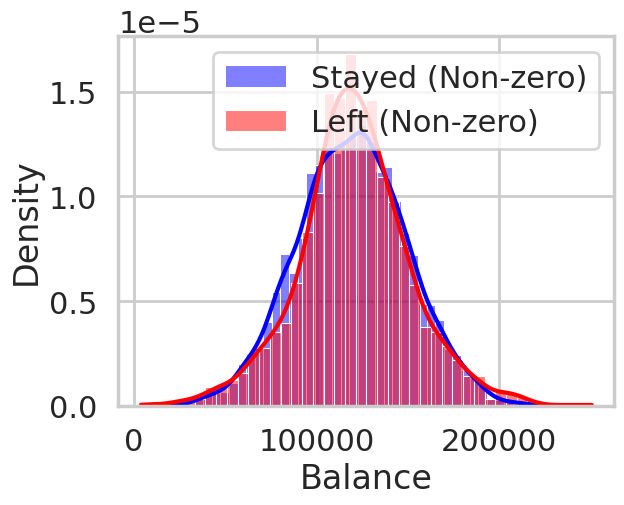

In [40]:
df_0_nonzero = df_0[df_0['Balance'] > 0]
df_1_nonzero = df_1[df_1['Balance'] > 0]
sns.histplot(df_0_nonzero['Balance'], color='blue', label='Stayed (Non-zero)', kde=True, stat='density', alpha=0.5)
sns.histplot(df_1_nonzero['Balance'], color='red', label='Left (Non-zero)', kde=True, stat='density', alpha=0.5)
plt.legend()
plt.show()

In [41]:
t_stat_nz, p_val_nz = scipy.stats.ttest_ind(df_0_nonzero['Balance'], df_1_nonzero['Balance'])
print(f'Non-zero Balance T-statistic: {t_stat_nz:.4f}, P-value: {p_val_nz:.4f}')

Non-zero Balance T-statistic: -1.3748, P-value: 0.1692


### Conclusion
**Partial Rejection.** While the overall balance shows a significant difference, the t-test for **non-zero balances** (p=0.1692) fails to reject the null. This suggests that the total balance difference is largely driven by the high number of customers with 0 balance in the 'Stayed' group, rather than a difference in the actual amount held by those with active balances.

## Hypothesis 4: Estimated Salary

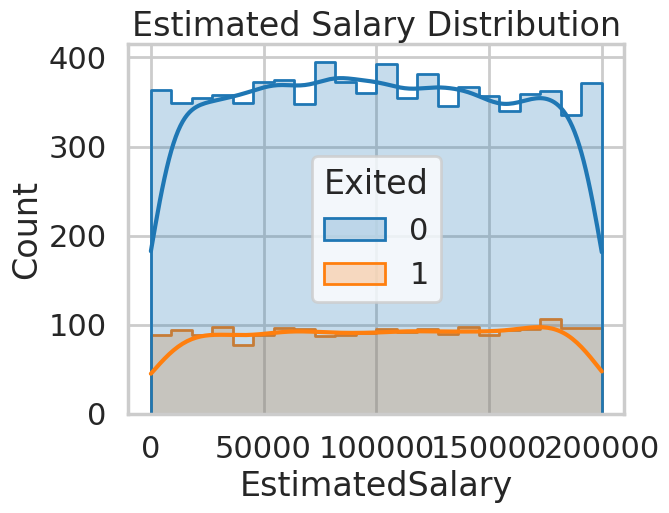

In [42]:
sns.histplot(data=df, x='EstimatedSalary', hue='Exited', kde=True, element='step')
plt.title('Estimated Salary Distribution')
plt.show()

In [43]:
t_stat_sal, p_val_sal = scipy.stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'])
print(f'Salary T-statistic: {t_stat_sal:.4f}, P-value: {p_val_sal:.4f}')

Salary T-statistic: -1.2097, P-value: 0.2264


### Using Bootstrapping

In [44]:
mean_sal_stayed = df_0['EstimatedSalary'].mean()
mean_sal_left = df_1['EstimatedSalary'].mean()
diff_means_sal = mean_sal_left - mean_sal_stayed
overall_mean_sal = df['EstimatedSalary'].mean()
sal_stayed_shifted = df_0['EstimatedSalary'] - mean_sal_stayed + overall_mean_sal
sal_left_shifted = df_1['EstimatedSalary'] - mean_sal_left + overall_mean_sal

In [45]:
bs_sal_stayed = bs_choice(sal_stayed_shifted, np.mean, 10000)
bs_sal_left = bs_choice(sal_left_shifted, np.mean, 10000)
bs_diff_sal = bs_sal_left - bs_sal_stayed

In [46]:
p_value_sal_bs = np.sum(bs_diff_sal >= diff_means_sal) / len(bs_diff_sal)
print(f'Bootstrap Salary p-value: {p_value_sal_bs}')

Bootstrap Salary p-value: 0.1143


### Conclusion
**Fail to Reject the Null Hypothesis.** Both the t-test (p=0.2264) and bootstrap p-value (~0.11) are greater than 0.05. There is no statistical evidence to suggest that estimated salary differs between customers who stay and those who leave.

## Final Conclusion
**Age** is the most helpful feature in predicting churning. It showed the most extreme difference in means and the lowest p-value. Additionally, the presence of a **Zero Balance** appears to be a stronger indicator than the specific Salary or Credit Score amount.